# **Capstone project: Providing data-driven suggestions for HR**

## Description and deliverables

This capstone project is an opportunity for you to analyze a dataset and build predictive models that can provide insights to the Human Resources (HR) department of a large consulting firm.

Upon completion, you will have two artifacts that you will be able to present to future employers. One is a brief one-page summary of this project that you will present to external stakeholders as the data professional in Salifort Motors. The other is a complete code notebook provided here. Based on your prior coursework, select one method to complete this project: use either a regression model or a machine learning model to predict whether an employee will leave the company. The exemplar following this actiivty shows both approaches, but you only need to do one.

In your deliverables, you will include the model evaluation (and interpretation if applicable), a data visualization(s) of your choice that is directly related to the question you ask, ethical considerations, and the resources you used to troubleshoot and find answers or solutions.


# **PACE stages**


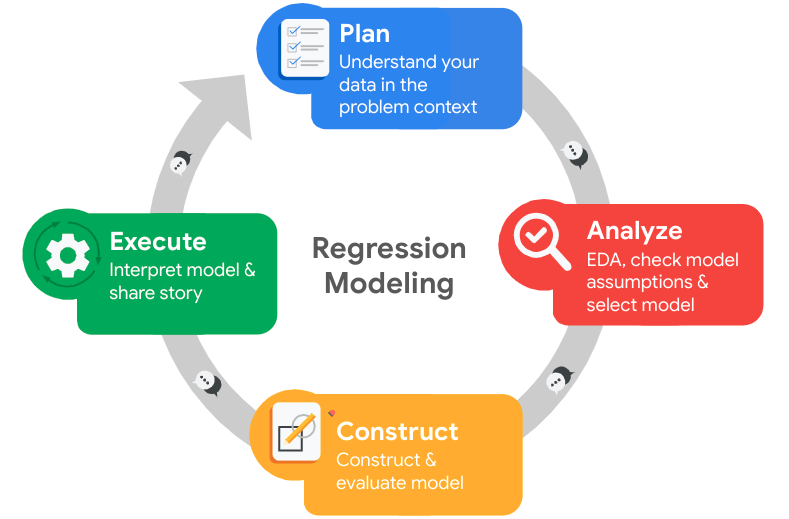

## **Pace: Plan**

Consider the questions in your PACE Strategy Document to reflect on the Plan stage.

In this stage, consider the following:

### Understand the business scenario and problem

The HR department at Salifort Motors wants to take some initiatives to improve employee satisfaction levels at the company. They collected data from employees, but now they don’t know what to do with it. They refer to you as a data analytics professional and ask you to provide data-driven suggestions based on your understanding of the data. They have the following question: what’s likely to make the employee leave the company?

Your goals in this project are to analyze the data collected by the HR department and to build a model that predicts whether or not an employee will leave the company.

If you can predict employees likely to quit, it might be possible to identify factors that contribute to their leaving. Because it is time-consuming and expensive to find, interview, and hire new employees, increasing employee retention will be beneficial to the company.

### Familiarize yourself with the HR dataset

The dataset that you'll be using in this lab contains 15,000 rows and 10 columns for the variables listed below. 

**Note:** you don't need to download any data to complete this lab. For more information about the data, refer to its source on [Kaggle](https://www.kaggle.com/datasets/mfaisalqureshi/hr-analytics-and-job-prediction?select=HR_comma_sep.csv).

Variable  |Description |
-----|-----|
satisfaction_level|Employee-reported job satisfaction level [0&ndash;1]|
last_evaluation|Score of employee's last performance review [0&ndash;1]|
number_project|Number of projects employee contributes to|
average_monthly_hours|Average number of hours employee worked per month|
time_spend_company|How long the employee has been with the company (years)
Work_accident|Whether or not the employee experienced an accident while at work
left|Whether or not the employee left the company
promotion_last_5years|Whether or not the employee was promoted in the last 5 years
Department|The employee's department
salary|The employee's salary (U.S. dollars)

💭
### Reflect on these questions as you complete the plan stage.

*  Who are your stakeholders for this project?
- What are you trying to solve or accomplish?
- What are your initial observations when you explore the data?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?




- The stakeholers of this project are the **HT departement of Salifort Motors**, which will use the analysis to identify the exmployees who are at risk leaving the company.

- The objective of the project is to **build a predictive model that identifies employees who are likely to leave the company**, and to determine the factors that contribute to their leaving. These insights can help the HR department develop strategies to improve employee satisfaction and retention, reducing the costs associated with hiring and training new employees.

- The dataset contains several features that may influence employee attrition, including satisfaction level, evaluation score, average monthly hours, number of projects, years at the company, salary level, and whether the employee received a promotion. These variables appear **to have potential relationships** with the target variable (`left`) and are likely to be useful predictors. Initial exploration also showed that `time_spend_compan` contains 824 potential outliers based on the IQR method. These observations suggest that further analysis and preprocessing may be needed before building a predictive model.

- The primary resource used during this stage is the dataset documentation on Kaggle:

Kaggle HR Analytics Dataset: https://www.kaggle.com/datasets/mfaisalqureshi/hr-analytics-and-job-prediction?select=HR_comma_sep.csv

- Although the dataset does not include protected characteristics such as gender, race, or ethnicity, ethical considerations remain important. **The predictive model should be used to support HR decision-making rather than replace human judgment**. It is also important to protect employee privacy, ensure the model is evaluated for unintended bias, and use predictions to improve employee well-being instead of penalizing employees who may be at risk of leaving. 

## Step 1. Imports

*   Import packages
*   Load dataset



### Import packages

In [2]:
# Import packages
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn import metrics

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# This is the function that helps plot feature importance
from xgboost import plot_importance

### Load dataset

`Pandas` is used to read a dataset called **`HR_capstone_dataset.csv`.**  As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [3]:
# RUN THIS CELL TO IMPORT YOUR DATA. 

# Load dataset into a dataframe
### YOUR CODE HERE ###
df0 = pd.read_csv("HR_capstone_dataset.csv")

# Display first few rows of the dataframe
df0.head(5)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## Step 2. Data Exploration (Initial EDA and data cleaning)

- Understand your variables
- Clean your dataset (missing data, redundant data, outliers)



### Gather basic information about the data

In [4]:
# Gather basic information about the data
df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


### Gather descriptive statistics about the data

In [5]:
df0.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


### Rename columns

As a data cleaning step, rename the columns as needed. Standardize the column names so that they are all in `snake_case`, correct any column names that are misspelled, and make column names more concise as needed.

In [6]:
# Display all column names
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

In [7]:
# Rename columns as needed
df0 = df0.rename(columns={"last_evaluation": "last_eval", "average_montly_hours": "avg_montly_hours",
                   "Work_accident": "work_accident", "Department": "department"})

# Display all column names after the update
df0.columns

Index(['satisfaction_level', 'last_eval', 'number_project', 'avg_montly_hours',
       'time_spend_company', 'work_accident', 'left', 'promotion_last_5years',
       'department', 'salary'],
      dtype='object')

### Check missing values

Check for any missing values in the data.

In [8]:
# Check for missing values
df0.isna().sum()

satisfaction_level       0
last_eval                0
number_project           0
avg_montly_hours         0
time_spend_company       0
work_accident            0
left                     0
promotion_last_5years    0
department               0
salary                   0
dtype: int64

### Check duplicates

Check for any duplicate entries in the data.

In [9]:
# Check for duplicates
df0.duplicated().any()

True

In [10]:
# Inspect some rows containing duplicates as needed
print(df0.duplicated().sum())
duplicates = df0[df0.duplicated()]
duplicates.head(n=10)

3008


,satisfaction_level,last_eval,number_project,avg_montly_hours,time_spend_company,work_accident,left,promotion_last_5years,department,salary
396,0.46,0.57,2,139,3,0,1,0,sales,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low
1516,0.40,0.50,2,127,3,0,1,0,IT,low
1616,0.37,0.46,2,156,3,0,1,0,sales,low
1696,0.39,0.56,2,160,3,0,1,0,sales,low
1833,0.10,0.85,6,266,4,0,1,0,sales,low
12000,0.38,0.53,2,157,3,0,1,0,sales,low


In [11]:
# Drop duplicates and save resulting dataframe in a new variable as needed
df = df0.drop_duplicates()

# Display first few rows of new dataframe as needed
df.head(n=10)

,satisfaction_level,last_eval,number_project,avg_montly_hours,time_spend_company,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
5,0.41,0.50,2,153,3,0,1,0,sales,low
6,0.10,0.77,6,247,4,0,1,0,sales,low
7,0.92,0.85,5,259,5,0,1,0,sales,low
8,0.89,1.00,5,224,5,0,1,0,sales,low
9,0.42,0.53,2,142,3,0,1,0,sales,low


### Check outliers

Check for outliers in the data.

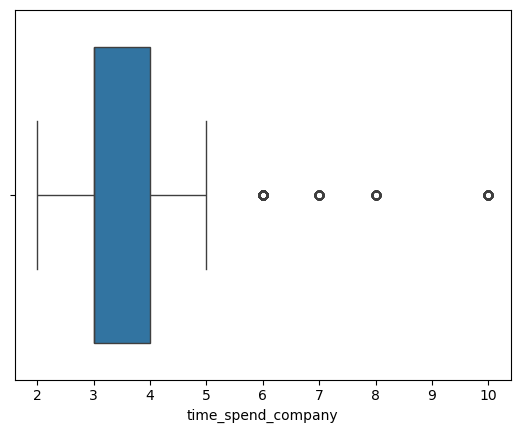

In [12]:
# Create a boxplot to visualize distribution of `time_spend_company` and detect any outliers
sns.boxplot(data=df, x="time_spend_company")
# plt.title("")
plt.show()

The box plot shows that employees have worked at the company for 3-4 years. A few observations lie beyond the upper whisker, indicating potential outliers among employees with unusually long tenure.

Employees with more than 5 years appear as outliers. 

In [13]:
# Determine the number of rows containing outliers
percentile25 = df['time_spend_company'].quantile(0.25)
percentile75 = df['time_spend_company'].quantile(0.75)

iqr = percentile75 - percentile25 
upper_limit = percentile75 + 1.5 * iqr 
lower_limit = percentile25 - 1.5 * iqr

outliers = df[
    (df['time_spend_company'] > upper_limit) |
    (df['time_spend_company'] < lower_limit)
]

print("Number of outliers:", len(outliers))

Number of outliers: 824


Certain types of models are more sensitive to outliers than others. When you get to the stage of building your model, consider whether to remove outliers, based on the type of model you decide to use.

# pAce: Analyze Stage
- Perform EDA (analyze relationships between variables)



💭
### Reflect on these questions as you complete the analyze stage.

- What did you observe about the relationships between variables?
- What do you observe about the distributions in the data?
- What transformations did you make with your data? Why did you chose to make those decisions?
- What are some purposes of EDA before constructing a predictive model?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)



- The visualizations show that several variables have a relationship with employee attrition. **Satisfaction level, number of projects, average monthly hours, time spent at the company, salary level, and promotion status** show clear differences between employees who left and those who stayed. In contrast, variables such as last evaluation score and work accidents show a weaker relationship with employee attrition.

- The data distributions vary across features. Satisfaction level and time spent at the company appear relatively concentrated, with some outliers observed in tenure. Average monthly hours and number of projects show a wider spread of values. Some variables also show differences in distribution depending on whether employees left or stayed, particularly for satisfaction level and working hours.

- Outliers were identified in the time spent at the company variable using the IQR method, but no values were removed at this stage. Further transformations such as encoding categorical variables and scaling may be applied later during model building.

- **Exploratory Data Analysis is used to understand the structure of the data**, identify patterns and relationships between variables, detect anomalies such as outliers or missing values, and determine which features may be useful for prediction. It also helps guide feature selection and prepares the data for building an effective predictive model.

- At this stage of analysis, it is important to ensure that interpretations of the data are not used to make unfair assumptions about employees. Although patterns related to attrition can be observed, they should not be interpreted as direct causes of employee behavior. Care should also be taken to avoid using the model in a way that could unfairly penalize employees or reinforce bias against certain groups or departments. The results should be used to support fair and informed HR decision-making.

## Step 2. Data Exploration (Continue EDA)

Begin by understanding how many employees left and what percentage of all employees this figure represents.

In [14]:
# Get numbers of people who left vs. stayed
print(df["left"].value_counts())

# Get percentages of people who left vs. stayed
print(df["left"].value_counts(normalize=True))

left
0    10000
1     1991
Name: count, dtype: int64
left
0    0.833959
1    0.166041
Name: proportion, dtype: float64


### Data visualizations

Now, examine variables that you're interested in, and create plots to visualize relationships between variables in the data.

In [15]:
print(df.columns)
df["employee_status"] = df["left"].map({0: "Stayed", 1: "Left"})

Index(['satisfaction_level', 'last_eval', 'number_project', 'avg_montly_hours',
       'time_spend_company', 'work_accident', 'left', 'promotion_last_5years',
       'department', 'salary'],
      dtype='object')


/var/folders/t9/3cpq4c0j0lnf6jk136v40w4h0000gn/T/ipykernel_17857/447525538.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["employee_status"] = df["left"].map({0: "Stayed", 1: "Left"})


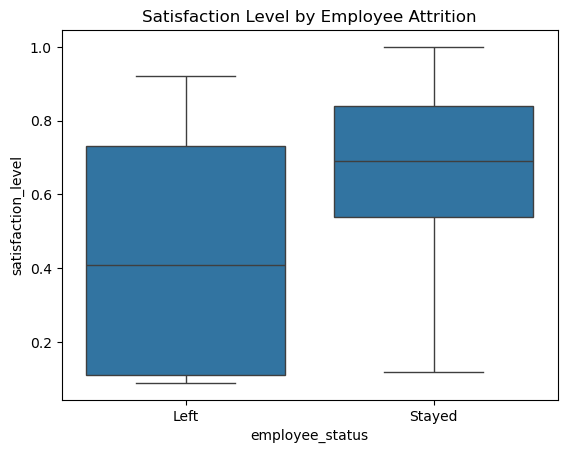

In [16]:
# Create a plot as needed
sns.boxplot(data=df, x="employee_status", y="satisfaction_level")
plt.title("Satisfaction Level by Employee Attrition")
plt.show()

Employees who left the company generally had lower satisfaction levels (approximately 0.1–0.7) than those who stayed (approximately 0.6–0.9). This suggests that satisfaction level is an important predictor of employee attrition.

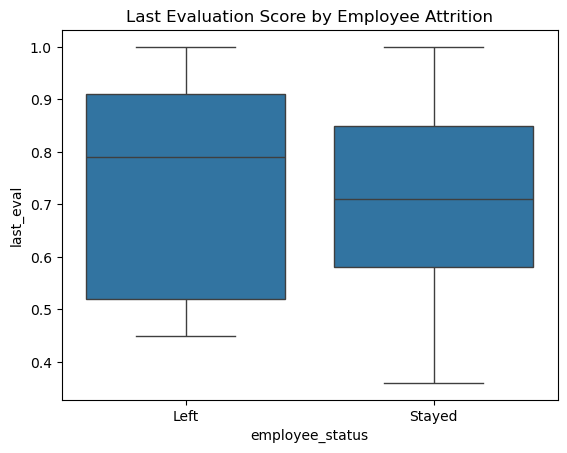

In [17]:
# Create a plot as needed
sns.boxplot(data=df, x="employee_status", y="last_eval")
plt.title("Last Evaluation Score by Employee Attrition")
plt.show()

Employees who left the company have evaluation scores that largely overlap with those of employees who stayed. This suggests that performance evaluation alone is not a strong indicator of employee attrition, as many employees who left still received high evaluation scores.

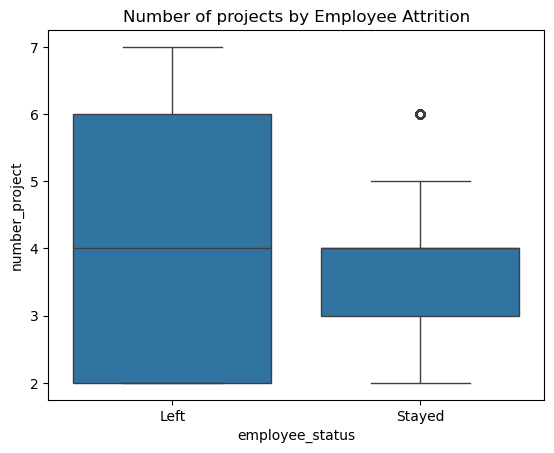

In [18]:
# Create a plot as needed
sns.boxplot(data=df, x="employee_status", y="number_project")
plt.title("Number of projects by Employee Attrition")
plt.show()

Employees who stayed at the company generally worked on 3 to 4 projects, while employees who left tended to have either fewer or more projects. This suggests that both underutilization and excessive workload may be associated with employee attrition.

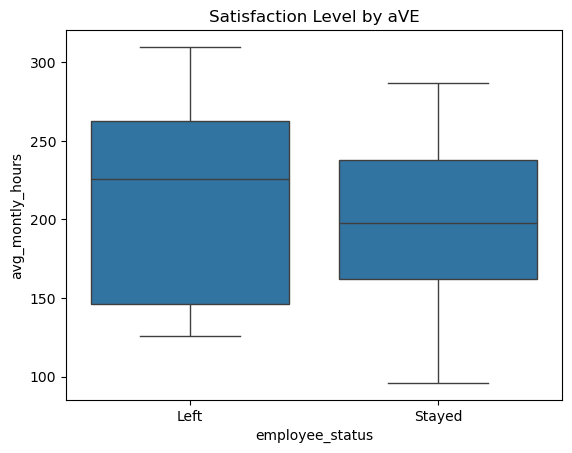

In [19]:
# Create a plot as needed
sns.boxplot(data=df, x="employee_status", y="avg_montly_hours")
plt.title("Satisfaction Level by aVE")
plt.show()

Employees who stayed at the company generally worked fewer hours compared to those who left, who tended to work longer hours. This suggests that higher working hours may be associated with employee attrition, although there is some overlap between the two groups.

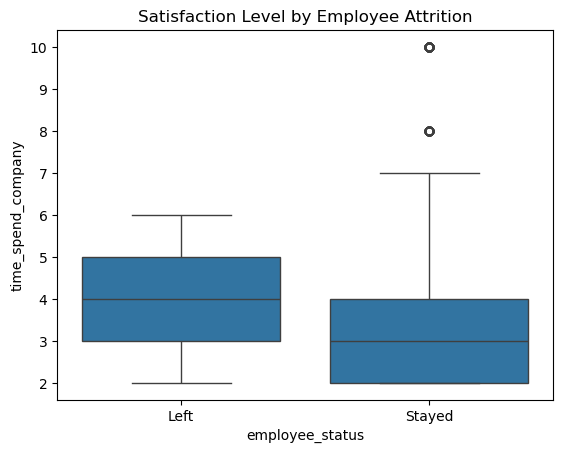

In [20]:
# Create a plot as needed
sns.boxplot(data=df, x="employee_status", y="time_spend_company")
plt.title("Satisfaction Level by Employee Attrition")
plt.show()

Employees who left the company generally spent more years at the company (approximately 3 to 5 years) than employees who stayed (approximately 2 to 4 years). This suggests that longer tenure may be associated with a higher likelihood of employee attrition.

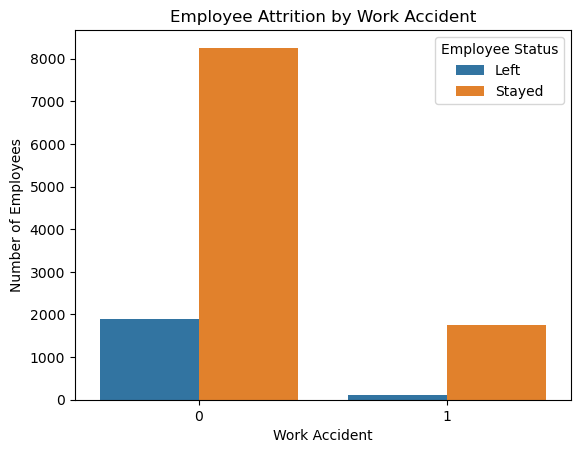

In [21]:
# Create a plot as needed
sns.countplot(data=df, x="work_accident", hue="employee_status")

plt.title("Employee Attrition by Work Accident")
plt.xlabel("Work Accident")
plt.ylabel("Number of Employees")
plt.legend(title="Employee Status")

plt.show()

The bar plot shows that employees who experienced a work accident were less likely to leave the company than those who did not. This suggests that having a work accident is associated with lower employee attrition.

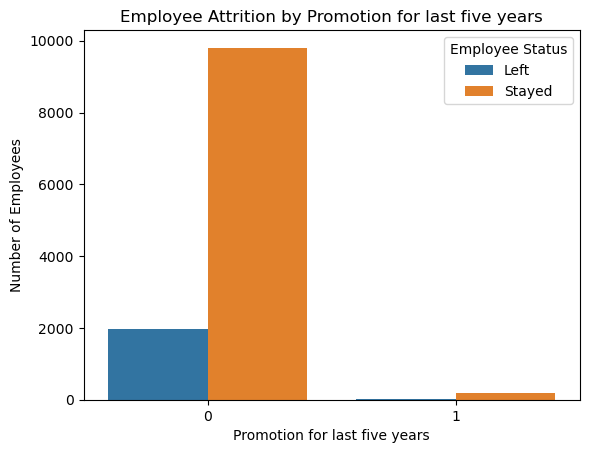

In [22]:
# Create a plot as needed
sns.countplot(data=df, x="promotion_last_5years", hue="employee_status")

plt.title("Employee Attrition by Promotion for last five years")
plt.xlabel("Promotion for last five years")
plt.ylabel("Number of Employees")
plt.legend(title="Employee Status")

plt.show()

The plot shows that none of the employees who left the company received a promotion in the last five years. This suggests that a lack of promotion may be associated with employee attrition.

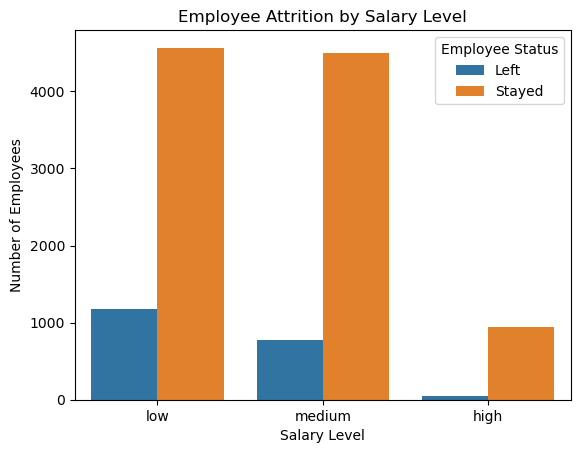

In [23]:
# Create a plot as needed
### YOUR CODE HERE ###
sns.countplot(data=df, x="salary", hue="employee_status")

plt.title("Employee Attrition by Salary Level")
plt.xlabel("Salary Level")
plt.ylabel("Number of Employees")
plt.legend(title="Employee Status")

plt.show();

The plot indicates that employee attrition decreases as salary level increases. Employees with low salaries have the highest attrition rates, while those with high salaries have the lowest.

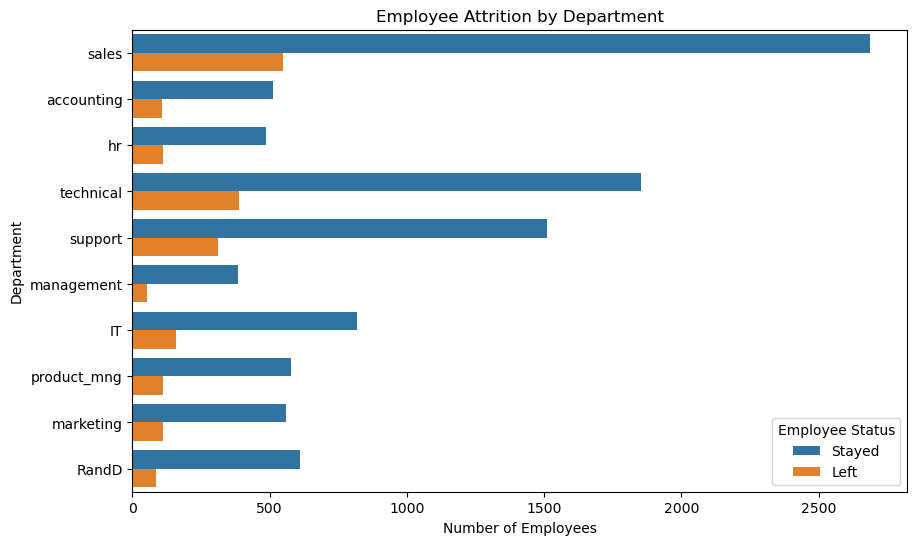

In [24]:
plt.figure(figsize=(10, 6))

sns.countplot(data=df, y="department", hue="left")

plt.title("Employee Attrition by Department")
plt.xlabel("Number of Employees")
plt.ylabel("Department")
plt.legend(title="Employee Status", labels=["Stayed", "Left"])

plt.show()

The plot shows that the Sales and Technical departments have the highest employee attrition.

### Insights

[What insights can you gather from the plots you created to visualize the data? Double-click to enter your responses here.]

The visualizations indicate that **satisfaction level, number of projects, average monthly working hours, time spent at the company, salary level, and promotions are associated with employee attrition**. In contrast, variables such as *last evaluation score and work accident* appear to be less informative predictors of employee attrition based on the exploratory analysis.

### Variable Encoding

In [25]:
# Drop the duplicate target column
df = df.drop(columns=["employee_status"])

# Create dummy variables
df = pd.get_dummies(
    df,
    columns=["department", "salary"],
    drop_first=True
)

# paCe: Construct Stage
- Determine which models are most appropriate
- Construct the model
- Confirm model assumptions
- Evaluate model results to determine how well your model fits the data


🔎
## Recall model assumptions

**Logistic Regression model assumptions**
- Outcome variable is categorical
- Observations are independent of each other
- No severe multicollinearity among X variables
- No extreme outliers
- Linear relationship between each X variable and the logit of the outcome variable
- Sufficiently large sample size





💭
### Reflect on these questions as you complete the constructing stage.

- Do you notice anything odd?

No major anomalies were observed. The validation scores were slightly higher than the cross-validation scores, but the differences were small and expected. Additionally, the test performance was consistent with the validation performance, indicating that the Random Forest model generalized well to unseen data.

- Which independent variables did you choose for the model and why?

We trained the models using all independent variables and also evaluated a version without `last_eval` and `work_accident`, as these variables showed a weak relationship with employee attrition during the EDA. However, the Random Forest model that included all variables achieved a higher precision score (0.986 compared with 0.976). Therefore, the final model retained all independent variables.

- Are each of the assumptions met?

Since we used tree-based models (Decision Tree and Random Forest), they do not require assumptions such as linearity or normality of the data. In addition, these models are generally robust to outliers, making them well suited for this dataset

- How well does your model fit the data?

The Random Forest model outperform that decision tree model across all metrics. The test metrics are very close to the validation metrics, suggesting that the Random Forest generalizes well and does not appear to overfit.

- Can you improve it? Is there anything you would change about the model?

The model could potentially be improved by exploring a wider range of hyperparameters during GridSearchCV. Additional feature engineering or testing more advanced ensemble methods, such as XGBoost or Gradient Boosting, may also improve performance, although these approaches require greater computational resources.

- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)

Sklearn, pandas

- Do you have any ethical considerations in this stage?


## Step 3. Model Building, Step 4. Results and Evaluation
- Fit a model that predicts the outcome variable using two or more independent variables
- Check model assumptions
- Evaluate the model

### Identify the type of prediction task.

Binary classification.

### Identify the types of models most appropriate for this task.

Several types of models are appropriate for this binary classification task, including logistic regression, decision trees, and ensemble methods such as random forests. The choice of model depends on factors such as interpretability, performance, and complexity. For example, logistic regression is highly interpretable, while tree-based models may capture more complex relationships in the data. For this project, we will compare all the models.

### Modeling

Add as many cells as you need to conduct the modeling process.

In [26]:
def make_results(model_name:str, model_object, metric:str):
    '''
    Arguments:
        model_name (string): what you want the model to be called in the output table
        model_object: a fit GridSearchCV object
        metric (string): precision, recall, f1, or accuracy

    Returns a pandas df with the F1, recall, precision, and accuracy scores
    for the model with the best mean 'metric' score across all validation folds.
    '''

    # Create dictionary that maps input metric to actual metric name in GridSearchCV
    metric_dict = {'precision': 'mean_test_precision',
                   'recall': 'mean_test_recall',
                   'f1': 'mean_test_f1',
                   'accuracy': 'mean_test_accuracy',
                   }

    # Get all the results from the CV and put them in a df
    cv_results = pd.DataFrame(model_object.cv_results_)

    # Isolate the row of the df with the max(metric) score
    best_estimator_results = cv_results.iloc[cv_results[metric_dict[metric]].idxmax(), :]

    # Extract accuracy, precision, recall, and f1 score from that row
    f1 = best_estimator_results.mean_test_f1
    recall = best_estimator_results.mean_test_recall
    precision = best_estimator_results.mean_test_precision
    accuracy = best_estimator_results.mean_test_accuracy

    # Create table of results
    table = pd.DataFrame({'model': [model_name],
                          'precision': [precision],
                          'recall': [recall],
                          'F1': [f1],
                          'accuracy': [accuracy],
                          },
                         )

    return table

In [27]:
# 1. Isolate X variables
X = df.drop(columns=['left'])

# 2. Isolate y variable
y = df['left']

# 3. Split into train and test sets
X_tr, X_test, y_tr, y_test = train_test_split(X, y, stratify=y,
                                              test_size=0.2, random_state=42)

# 4. Split into train and validate sets
X_train, X_val, y_train, y_val = train_test_split(X_tr, y_tr, stratify=y_tr,
                                                  test_size=0.25, random_state=42)

In this case, **recall is more important than precision**. The goal is to correctly identify employees who are likely to leave the company. If the model fails to identify an employee who will leave (false negative), the company may miss the opportunity to take proactive measures to retain them. Therefore, minimizing false negatives is more important than minimizing false positives in this context.

### Decision Tree

In [28]:
decision_tree = DecisionTreeClassifier(random_state=42)

dt_cv_params = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'criterion': ['gini', 'entropy']
}

# 3. Define a list of scoring metrics to capture
scoring = ['accuracy', 'precision', 'recall', 'f1']

# 4. Instantiate the GridSearchCV object
dt_cv = GridSearchCV(decision_tree, dt_cv_params, scoring=scoring, cv=4, refit='recall')

In [29]:
%%time
dt_cv.fit(X_train, y_train)

CPU times: user 2.62 s, sys: 30.4 ms, total: 2.65 s
Wall time: 2.29 s


GridSearchCV(cv=4, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 10, None],
                         'min_samples_leaf': [1, 2, 5],
                         'min_samples_split': [2, 5, 10]},
             refit='recall', scoring=['accuracy', 'precision', 'recall', 'f1'])

In [30]:
results = make_results('DT cv', dt_cv, 'recall')
results

,model,precision,recall,F1,accuracy
0,DT cv,0.796403,0.918818,0.853053,0.947455


### Random Forest

In [31]:
# 1. Instantiate the random forest classifier
rf = RandomForestClassifier(random_state=42)

# 2. Create a dictionary of hyperparameters to tune
cv_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}

# 3. Define a list of scoring metrics to capture
scoring = ['accuracy', 'precision', 'recall', 'f1']

# 4. Instantiate the GridSearchCV object
rf_cv = GridSearchCV(rf, cv_params, scoring=scoring, cv=4, refit='recall')

In [ ]:
%%time
rf_cv.fit(X_train, y_train)

In [ ]:
rf_cv_results = make_results('RF cv', rf_cv, 'recall')
results = pd.concat([results, rf_cv_results], axis=0)
results

,model,precision,recall,F1,accuracy
0,DT cv,0.796403,0.918818,0.853053,0.947455
0,RF cv,0.986454,0.905431,0.943987,0.982207


### Model Selection

In this step, we will use the best decision tree, the best random forest model and the best XGBoost model to predict on the validation data. Whichever performs better will be selected as the champion model.

In [ ]:
def get_test_scores(model_name:str, preds, y_test_data):
    '''
    Generate a table of test scores.

    In:
        model_name (string): Your choice: how the model will be named in the output table
        preds: numpy array of test predictions
        y_test_data: numpy array of y_test data

    Out:
        table: a pandas df of precision, recall, f1, and accuracy scores for your model
    '''
    accuracy = metrics.accuracy_score(y_test_data, preds)
    precision = metrics.precision_score(y_test_data, preds)
    recall = metrics.recall_score(y_test_data, preds)
    f1 = metrics.f1_score(y_test_data, preds)

    table = pd.DataFrame({'model': [model_name],
                          'precision': [precision],
                          'recall': [recall],
                          'F1': [f1],
                          'accuracy': [accuracy]
                          })

    return table

In [ ]:
# Use decision tree model to predict on validation data
dt_val_preds = dt_cv.best_estimator_.predict(X_val)

In [ ]:
# Use random forest model to predict on validation data
rf_val_preds = rf_cv.best_estimator_.predict(X_val)

In [ ]:
dt_val_scores = get_test_scores('DT val', dt_val_preds, y_val)
rf_val_scores = get_test_scores('RF val', rf_val_preds, y_val)

results = pd.concat([results, dt_val_scores, rf_val_scores], axis=0)
results

,model,precision,recall,F1,accuracy
0,DT cv,0.796403,0.918818,0.853053,0.947455
0,RF cv,0.986454,0.905431,0.943987,0.982207
0,DT val,0.827740,0.929648,0.875740,0.956214
0,RF val,0.978610,0.919598,0.948187,0.983319


Notice that the scores went down from the training scores across all metrics, but only by very little. This means that the model did not overfit the training data.

# pacE: Execute Stage
- Interpret model performance and results
- Share actionable steps with stakeholders



✏
## Recall evaluation metrics

- **AUC** is the area under the ROC curve; it's also considered the probability that the model ranks a random positive example more highly than a random negative example.
- **Precision** measures the proportion of data points predicted as True that are actually True, in other words, the proportion of positive predictions that are true positives.
- **Recall** measures the proportion of data points that are predicted as True, out of all the data points that are actually True. In other words, it measures the proportion of positives that are correctly classified.
- **Accuracy** measures the proportion of data points that are correctly classified.
- **F1-score** is an aggregation of precision and recall.






💭
### Reflect on these questions as you complete the executing stage.

- What key insights emerged from your model(s)?
- What business recommendations do you propose based on the models built?
- What potential recommendations would you make to your manager/company?
- Do you think your model could be improved? Why or why not? How?
- Given what you know about the data and the models you were using, what other questions could you address for the team?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?



- The Random Forest model outperformed the Decision Tree and generalized well to unseen data. The feature importance analysis showed that satisfaction level was the strongest predictor of employee attrition, followed by number of projects, time spent at the company, average monthly hours, and last evaluation. These findings suggest that employee workload, tenure, and satisfaction are the main factors associated with attrition.

- Based on the model results, the HR department should focus on improving employee satisfaction and monitoring employees with high workloads or long working hours. Employees who have spent several years at the company or are managing many projects may also benefit from regular check-ins and career development discussions. The model can be used to identify employees at higher risk of leaving so that proactive retention strategies can be implemented.

- I would recommend using the model as a decision-support tool to help identify employees who may be at risk of leaving. The company should also collect regular employee feedback through satisfaction surveys and evaluate workload distribution to address potential causes of attrition. In addition, the model should be retrained periodically as new employee data becomes available to maintain its predictive performance.

- Yes. The model could be improved by collecting additional employee data and feedback, particularly for employees who leave the company, to provide more predictive information. Further improvements could also be achieved through additional feature engineering, tuning a wider range of hyperparameters, or evaluating more advanced ensemble models.

- The model could be extended to answer additional business questions, such as which factors most influence employee satisfaction, whether attrition differs across departments or salary levels.

- The model should be used to support HR decision-making rather than replace it. Employees identified as being at risk of leaving should be offered additional support and development opportunities rather than being treated unfairly. The model should also be monitored regularly to ensure that its predictions do not introduce unintended bias or lead to unfair decisions.

**Use champion model to predict on test data¶**

In [ ]:
# Use XGBoost model to predict on test data
rf_test_preds = rf_cv.best_estimator_.predict(X_test)

# Get test scores for XGBoost model
rf_test_scores = get_test_scores('RF test', rf_test_preds, y_test)

# Append to the results table
results = pd.concat([results, rf_test_scores], axis=0)
results

,model,precision,recall,F1,accuracy
0,DT cv,0.796403,0.918818,0.853053,0.947455
0,RF cv,0.986454,0.905431,0.943987,0.982207
0,DT val,0.827740,0.929648,0.875740,0.956214
0,RF val,0.978610,0.919598,0.948187,0.983319
0,RF test,0.986667,0.929648,0.957309,0.986244


## Step 4. Results and Evaluation
- Interpret model
- Evaluate model performance using metrics
- Prepare results, visualizations, and actionable steps to share with stakeholders




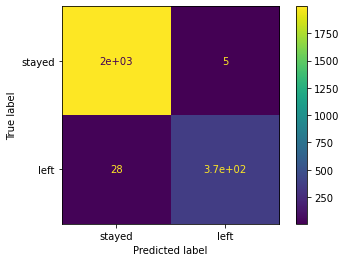

In [ ]:
# Generate array of values for confusion matrix
cm = metrics.confusion_matrix(y_test, rf_test_preds, labels=rf_cv.classes_)

# Plot confusion matrix
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm,
                             display_labels=['stayed', 'left'])
disp.plot();

In [ ]:
df["left"].value_counts(normalize=True)

0    0.833959
1    0.166041
Name: left, dtype: float64

                   Feature  Importance
0       satisfaction_level    0.326271
2           number_project    0.177455
4       time_spend_company    0.165088
3         avg_montly_hours    0.153912
1                last_eval    0.135270
5            work_accident    0.008068
16              salary_low    0.007007
17           salary_medium    0.004536
13        department_sales    0.004003
15    department_technical    0.003671
14      department_support    0.003097
10   department_management    0.001934
11    department_marketing    0.001875
8    department_accounting    0.001726
7         department_RandD    0.001631
9            department_hr    0.001597
6    promotion_last_5years    0.001463
12  department_product_mng    0.001396


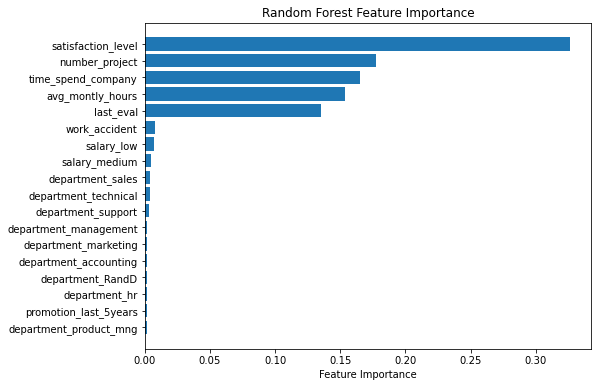

In [ ]:
rf_best = rf_cv.best_estimator_

importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_best.feature_importances_
})

importances = importances.sort_values(by='Importance', ascending=False)

print(importances)

importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_cv.best_estimator_.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,6))
plt.barh(importances['Feature'], importances['Importance'])
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importance')
plt.gca().invert_yaxis()
plt.show()

                   Feature  Importance
0       satisfaction_level    0.440582
4       time_spend_company    0.252475
2           number_project    0.218969
1                last_eval    0.087974
11    department_marketing    0.000000
16              salary_low    0.000000
15    department_technical    0.000000
14      department_support    0.000000
13        department_sales    0.000000
12  department_product_mng    0.000000
9            department_hr    0.000000
10   department_management    0.000000
8    department_accounting    0.000000
7         department_RandD    0.000000
6    promotion_last_5years    0.000000
5            work_accident    0.000000
3         avg_montly_hours    0.000000
17           salary_medium    0.000000


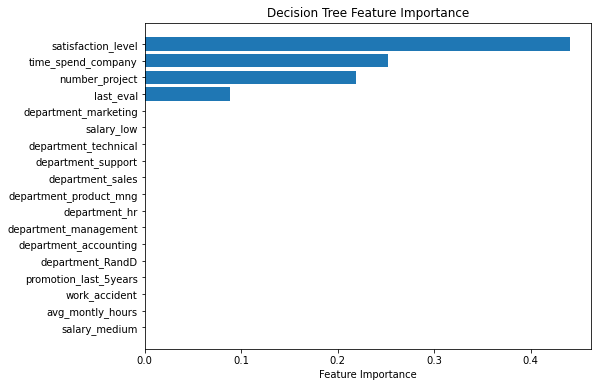

In [ ]:
dt_best = dt_cv.best_estimator_

importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': dt_best.feature_importances_
})

importances = importances.sort_values(by='Importance', ascending=False)

print(importances)

importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': dt_cv.best_estimator_.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,6))
plt.barh(importances['Feature'], importances['Importance'])
plt.xlabel('Feature Importance')
plt.title('Decision Tree Feature Importance')
plt.gca().invert_yaxis()
plt.show()

### Summary of model results


- From the confusion matrix, the model produced more false positives (28) than false negatives (5), which is expected because the GridSearchCV was configured to optimize recall. By prioritizing recall, the model minimizes the number of employees who are incorrectly predicted to stay when they are actually likely to leave, even if this results in more employees being incorrectly flagged as at risk of leaving. As a result, HR is less likely to miss employees who are truly at risk of leaving, which is the more costly mistake in this business scenario.

- The feature importance analysis showed that the Random Forest and Decision Tree relied on similar key predictors but assigned different levels of importance to them. For the Random Forest model, the most influential features were `satisfaction_level`,`number_project`, `time_spend_company`, `avg_monthly_hours`, and `last_eval`, while variables such as `salary`and some `department` indicators contributed relatively little. Similarly, the Decision Tree identified `satisfaction_level`, `time_spend_company`, `number_project`, and `last_eval` as its most important predictors.

- Although both models agreed on several important features, the Random Forest relied on a broader set of features for its predictions, whereas the Decision Tree concentrated most of its predictive power on a smaller subset of features.

- An interesting finding is that `last_eval` and `work_accident` appeared to have a weak individual relationship with employee attrition during the EDA, yet the Random Forest assigned them relatively higher feature importance. This suggests that, while these variables are not strong predictors on their own, they contribute to the model when considered together with other features. This highlights an important difference between EDA and machine learning models: EDA evaluates variables individually, whereas Random Forest can capture complex interactions that are not evident from univariate visualizations.

### Conclusion, Recommendations, Next Steps

- The analysis identified several factors associated with employee attrition. Among them, employee satisfaction level, number of projects, time spent at the company, average monthly working hours, and last evaluation were the most influential predictors. The Random Forest model achieved the best predictive performance and generalized well to unseen data, making it a suitable tool for identifying employees who may be at risk of leaving.

#### Recommendations
- Improve employee satisfaction by regularly collecting feedback and addressing workplace concerns.
- Monitor employees with high workloads or long working hours to reduce the risk of burnout.
- Conduct regular career development and performance discussions, particularly for employees who have spent several years at the company.
- Use the predictive model as a decision-support tool to identify employees who may benefit from retention initiatives.

#### Next Steps
- Collect additional employee data, such as engagement surveys or exit interview feedback, to improve future models.
- Retrain and evaluate the model periodically as new employee data becomes available.
- Explore additional machine learning models and feature engineering techniques to further improve predictive performance.
- Monitor the model for potential bias and ensure that predictions are used to support fair and transparent HR decision-making.

**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged.